# Pre-peak rSFMS: SF, Balmer non-detections, and non-SF spaxels

This notebook extends `20260831_check_SF_fraction_pre_peak.ipynb` without modifying it.
It keeps the same live pre-peak sample, inclination cut ($i<80^\circ$), valid-disc
footprint, component geometry (including the minimum component $R/R_e$ for
NGC4567_8), and SF/ND/NSF masks.

The purpose is to **locate the previously unplotted categories in the resolved
stellar-mass--Halpha-SFR plane**, not to fit a censored rSFMS.

| Colour | Source category | Meaning of the plotted ordinate |
|---|---|---|
| Blue | SF: original HII + EW > 6 Angstrom + intrinsic Halpha dispersion < 45 km/s | Original selected-SF value |
| Orange | ND: at least one Balmer line fails S/N or flux-floor detection | Stored pipeline proxy/substitution; not a formal upper limit |
| Red | NSF: both Balmer lines detected, but original SF selection fails | Halpha-equivalent SFR; not automatically a star-formation measurement |

Every panel has the **same pooled pre-peak SF-only distribution in light gray**,
including the target itself. A single dotted **concave hull connects actual outer
points** of the pooled SF+ND+NSF distribution. All finite points, including
outliers, remain inside or on this outline. There is no density calculation,
smoothing, or percentile cut. Black dashed and blue dashed lines are pooled and
individual **selected-SF-only, unweighted pixel-level OLS** guides, respectively.
Neither line uses ND or NSF, and neither is a censored fit or an equal-galaxy
population inference.

## Important: an `UPPER` name is not a confidence limit

The current `SFR+Z.py` function `modify_Balmer_not_detected_map` constructs the
ND contribution to `LOGSFR_SURFACE_DENSITY` from
`max(NOISE, raw Halpha flux)`, without a Balmer-decrement correction.
The notebook checks that this construction matches the live stored maps.
Thus an orange horizontal floor can be imposed by the pipeline, not by galaxy
physics. Hbeta-only ND can still have detected Halpha; it is not an Halpha
non-detection. No upper-limit arrows are drawn for these placeholders.

For NSF, an upper-bound interpretation of the SF contribution would require
explicit assumptions about the emission source and attenuation. Failure of an
EW, dispersion, or classification gate alone does not define a numerical
confidence limit. No new dust correction, sensitivity prescription, or SFR
calibration is introduced here.


## 1. Source configuration

The original configuration is retained. Category colours encode classes, not galaxy identity.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_EDGES = np.linspace(6.0, 10.0, 13)
R_EDGES = np.arange(0.0, 1.6 + 0.2, 0.2)
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: pre-peak, science-ready primary sample with inclination < 80 deg")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")

# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: pre-peak, science-ready primary sample with inclination < 80 deg
No additional inclination correction is applied to either surface-density map.


## 2. Source mask and geometry helpers

Relevant helpers are copied verbatim from source cell 5; fraction-profile plotting helpers are omitted.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {a.shape for a in (mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr)}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps



## 3. Live pre-peak inventory and original selection QC

This is the source inventory/QC cell, unchanged. The following cells do not alter its masks or sample.


In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir() if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS]),
            "ew_path": first_existing([folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
        })
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one"
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
prepeak_candidates = inventory.loc[
    inventory.stage.eq("pre-peak") & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values("GALID").reset_index(drop=True)

map_cache = {}
qc_rows = []
for row in prepeak_candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path), ("ew", row.ew_path), ("mask", row.mask_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            if np.any(maps["sf_mask"] & ~maps["valid_disc_mask"]):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        map_cache[row.GALID] = maps
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid_stellar_pixels": int(maps["valid_disc_mask"].sum()) if maps is not None else 0,
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()) if maps is not None else 0,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

PREPEAK_QC = pd.DataFrame(qc_rows)
prepeak = prepeak_candidates.loc[
    prepeak_candidates.GALID.isin(PREPEAK_QC.loc[PREPEAK_QC.QC_flag.eq("OK"), "GALID"])
].copy()

display(PREPEAK_QC)
print(f"Pre-peak primary products passing QC: {len(prepeak)}/{len(prepeak_candidates)}")
print("Included:", ", ".join(prepeak.GALID))
if len(prepeak) == 0:
    raise RuntimeError("No pre-peak galaxies passed the live product QC")

,GALID,components,stage,inclination_deg,N_valid_stellar_pixels,N_selected_SF_pixels,wcs_separation_arcsec,QC_flag
0,NGC4189,NGC4189,pre-peak,42.0,177204,96364,0.0,OK
1,NGC4254,NGC4254,pre-peak,39.0,1043477,661963,0.0,OK
2,NGC4294,NGC4294,pre-peak,74.0,179355,68833,0.0,OK
3,NGC4321,NGC4321,pre-peak,32.0,970159,454131,0.0,OK
4,NGC4351,NGC4351,pre-peak,48.0,180133,30711,0.0,OK
5,NGC4383,NGC4383,pre-peak,56.0,227031,25212,0.0,OK
6,NGC4535,NGC4535,pre-peak,48.0,525101,187113,0.0,OK
7,NGC4567_8,"NGC4567,NGC4568",pre-peak,70.0,510118,222533,0.0,OK


Pre-peak primary products passing QC: 8/8
Included: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8


## 4. All-spaxel ordinates, category coverage, and provenance

Use `LOGSFR_SURFACE_DENSITY` for the three coloured classes, but keep
`LOGSFR_SURFACE_DENSITY_HII` for the **unchanged source SF selection**.
Require equality of these two maps on selected SF spaxels. Report every missing
ordinate rather than silently shrinking the valid-disc denominator.

The ND-construction check below derives the log flux-to-surface-density offset
from Balmer-detected pixels in each stored product, then verifies the ND values
against `max(NOISE, raw Halpha)`. This is a consistency check, not a new calibration.


In [4]:
CATEGORY_KEYS = {"SF": "sf_mask", "ND": "nd_mask", "NSF": "nsf_mask"}
rsfms_cache = {}
coverage_rows, provenance_rows, nd_rows = [], [], []

for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    x = maps["log_sigma_star"]
    y, y_header = load_fits_map(row.sfr_path, ALL_SFR_HDU, return_header=True)
    valid = maps["valid_disc_mask"]
    if y.shape != x.shape:
        raise ValueError(f"{row.GALID}: all-spaxel SFR map shape mismatch")
    separation = celestial_wcs_separation_arcsec(maps["mass_header"], y_header, x.shape)
    if not np.isfinite(separation) or separation > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: all-spaxel SFR WCS mismatch")
    finite_xy = valid & np.isfinite(x) & np.isfinite(y)
    sf = maps["sf_mask"]
    if not np.all(finite_xy[sf]):
        raise AssertionError(f"{row.GALID}: selected SF has an unavailable ordinate")
    np.testing.assert_allclose(
        y[sf], maps["log_sigma_sfr"][sf], rtol=0, atol=1e-10,
        err_msg=f"{row.GALID}: all-spaxel map disagrees with original SF values",
    )
    class_sum = sum(maps[key].astype(np.int8) for key in CATEGORY_KEYS.values())
    np.testing.assert_array_equal(class_sum, valid.astype(np.int8))
    rsfms_cache[row.GALID] = {"x": x, "y": y, "finite_xy": finite_xy}

    for label, key in CATEGORY_KEYS.items():
        selected = maps[key]
        n_class = int(selected.sum())
        n_plotted = int((selected & finite_xy).sum())
        coverage_rows.append({
            "GALID": row.GALID, "category": label,
            "N_valid": int(valid.sum()), "N_class": n_class,
            "fraction_of_valid": n_class / int(valid.sum()),
            "N_plotted": n_plotted, "N_missing_y": n_class - n_plotted,
        })

    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        raw_ha = np.asarray(hdul["HA6562_FLUX"].data, dtype=float)
        corrected_ha = np.asarray(hdul["HA6562_FLUX_CORR"].data, dtype=float)
        floor = float(header["NOISE"])
        calibration_mask = (finite_xy & maps["balmer_detected_mask"]
                            & np.isfinite(corrected_ha) & (corrected_ha > 0))
        if not calibration_mask.any():
            raise AssertionError(f"{row.GALID}: no detected pixels to verify flux conversion")
        offset_samples = y[calibration_mask] - np.log10(corrected_ha[calibration_mask])
        log_offset = float(np.median(offset_samples))
        np.testing.assert_allclose(offset_samples, log_offset, rtol=0, atol=1e-6)
        check_nd = maps["nd_mask"] & finite_xy & np.isfinite(raw_ha)
        expected_nd = np.log10(np.maximum(floor, raw_ha[check_nd])) + log_offset
        np.testing.assert_allclose(
            y[check_nd], expected_nd, rtol=0, atol=1e-6,
            err_msg=f"{row.GALID}: stored ND construction differs from current pipeline",
        )
        max_delta = (float(np.max(np.abs(y[check_nd] - expected_nd)))
                     if check_nd.any() else np.nan)
        provenance_rows.append({
            "GALID": row.GALID, "sfr_path": str(row.sfr_path),
            "ordinate_HDU": ALL_SFR_HDU, "stored_BUNIT": y_header.get("BUNIT", ""),
            **{key: header.get(key, "not recorded")
               for key in ("CUT_SN", "NOISE", "BPTMODE", "DUSTLAW", "SFRCOEF")},
            "ND_checked": int(check_nd.sum()), "ND_max_delta_dex": max_delta,
        })
        nd = maps["nd_mask"]
        ha_det, hb_det = maps["line_detected"]["HA6562"], maps["line_detected"]["HB4861"]
        nd_rows.append({
            "GALID": row.GALID, "N_ND": int(nd.sum()),
            "Halpha_detected_Hbeta_failed": int((nd & ha_det & ~hb_det).sum()),
            "Halpha_failed_Hbeta_detected": int((nd & ~ha_det & hb_det).sum()),
            "both_failed": int((nd & ~ha_det & ~hb_det).sum()),
            "invalid_Balmer_measurement": int(maps["nd_invalid_mask"].sum()),
            "ND_at_raw_Halpha_floor": int((check_nd & (raw_ha <= floor)).sum()),
        })

CATEGORY_COVERAGE = pd.DataFrame(coverage_rows)
SFR_PROVENANCE = pd.DataFrame(provenance_rows)
ND_DETAILS = pd.DataFrame(nd_rows)
assert (CATEGORY_COVERAGE.N_plotted + CATEGORY_COVERAGE.N_missing_y
        == CATEGORY_COVERAGE.N_class).all()
assert np.array_equal(
    ND_DETAILS[["Halpha_detected_Hbeta_failed", "Halpha_failed_Hbeta_detected",
                "both_failed"]].sum(axis=1).to_numpy(),
    ND_DETAILS.N_ND.to_numpy(),
)
display(CATEGORY_COVERAGE)
display(ND_DETAILS)
display(SFR_PROVENANCE)
print("Verified: SF/ND/NSF partition the original valid footprint.")
print("Verified: all selected-SF ordinates equal the original HII-map values.")
print("Verified: finite ND values follow the stored raw-Halpha/floor substitution.")
print("Stored BUNIT is reported verbatim; axis units follow the pipeline surface-density definition.")


,GALID,category,N_valid,N_class,fraction_of_valid,N_plotted,N_missing_y
0,NGC4189,SF,177204,96364,0.543803,96364,0
1,NGC4189,ND,177204,45185,0.254989,45185,0
2,NGC4189,NSF,177204,35655,0.201209,35655,0
3,NGC4254,SF,1043477,661963,0.634382,661963,0
4,NGC4254,ND,1043477,179988,0.172489,179988,0
5,NGC4254,NSF,1043477,201526,0.193129,201526,0
6,NGC4294,SF,179355,68833,0.383781,68833,0
7,NGC4294,ND,179355,51275,0.285886,51275,0
8,NGC4294,NSF,179355,59247,0.330334,59247,0
9,NGC4321,SF,970159,454131,0.468100,454131,0


,GALID,N_ND,Halpha_detected_Hbeta_failed,Halpha_failed_Hbeta_detected,both_failed,invalid_Balmer_measurement,ND_at_raw_Halpha_floor
0,NGC4189,45185,23059,0,22126,0,22126
1,NGC4254,179988,154910,0,25078,0,25078
2,NGC4294,51275,41419,0,9856,0,9856
3,NGC4321,141086,132726,0,8360,0,8360
4,NGC4351,132740,41481,0,91259,0,91259
5,NGC4383,65261,58985,0,6276,0,6276
6,NGC4535,130687,129911,0,776,0,776
7,NGC4567_8,185310,108663,0,76647,0,76647


,GALID,sfr_path,ordinate_HDU,stored_BUNIT,CUT_SN,NOISE,BPTMODE,DUSTLAW,SFRCOEF,ND_checked,ND_max_delta_dex
0,NGC4189,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,45185,6.661338e-15
1,NGC4254,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,179988,8.038015e-14
2,NGC4294,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,51275,3.552714e-14
3,NGC4321,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,141086,4.884981e-15
4,NGC4351,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,132740,8.881784e-15
5,NGC4383,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,65261,6.750156e-14
6,NGC4535,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,130687,3.996803e-15
7,NGC4567_8,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,185310,3.552714e-15


Verified: SF/ND/NSF partition the original valid footprint.
Verified: all selected-SF ordinates equal the original HII-map values.
Verified: finite ND values follow the stored raw-Halpha/floor substitution.
Stored BUNIT is reported verbatim; axis units follow the pipeline surface-density definition.


## 5. Descriptive OLS guides

Fit $y=a(x-8)+b_8$ by ordinary least squares, with
$x=\log\Sigma_\star$ and $y=\log\Sigma_{\rm SFR,H\alpha}$.
Use **all selected-SF pixels** in each relevant sample, matching the grey
SF-only background. The all-category dotted point-connected outline does not enter either fit.
No display subsampling or axis-range cut enters a fit.

The pooled guide is pixel-weighted: large footprints contribute more pixels.
Pixels may share the PSF and fitted bins. No standard errors, p-values, or
environmental claims are derived. An individual line needs at least 20 selected-SF
pixels and nonzero mass spread; this display threshold does not change any mask.
Lines are drawn only across the mass range used by their own fit.


In [5]:
OLS_PIVOT = 8.0
MIN_OLS_PIXELS = 20


def ols_guide(x, y):
    good = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x)[good], np.asarray(y)[good]
    result = {"N_SF": int(x.size), "slope": np.nan, "intercept_at_8": np.nan,
              "x_min": np.nan, "x_max": np.nan, "status": "insufficient_SF"}
    if x.size < MIN_OLS_PIXELS:
        return result
    xmean, ymean = float(x.mean()), float(y.mean())
    centered_x = x - xmean
    denominator = float(np.dot(centered_x, centered_x))
    if denominator <= 0:
        result["status"] = "zero_mass_spread"
        return result
    slope = float(np.dot(centered_x, y - ymean) / denominator)
    result.update(slope=slope, intercept_at_8=ymean + slope * (OLS_PIVOT - xmean),
                  x_min=float(x.min()), x_max=float(x.max()), status="OK")
    return result


pooled_x = np.concatenate([rsfms_cache[g]["x"][rsfms_cache[g]["finite_xy"]]
                           for g in prepeak.GALID])
pooled_y = np.concatenate([rsfms_cache[g]["y"][rsfms_cache[g]["finite_xy"]]
                           for g in prepeak.GALID])
pooled_sf_x = np.concatenate([rsfms_cache[g]["x"][map_cache[g]["sf_mask"]]
                              for g in prepeak.GALID])
pooled_sf_y = np.concatenate([rsfms_cache[g]["y"][map_cache[g]["sf_mask"]]
                              for g in prepeak.GALID])
if pooled_x.size == 0:
    raise RuntimeError("No finite pre-peak ordinates available")
assert pooled_x.size == int(CATEGORY_COVERAGE.N_plotted.sum())
assert pooled_sf_x.size == int(CATEGORY_COVERAGE.query("category == 'SF'").N_class.sum())

ensemble_ols = ols_guide(pooled_sf_x, pooled_sf_y)
individual_ols = {}
for galid in prepeak.GALID:
    mask = map_cache[galid]["sf_mask"]
    data = rsfms_cache[galid]
    individual_ols[galid] = ols_guide(data["x"][mask], data["y"][mask])

OLS_SUMMARY = pd.DataFrame(
    [{"sample": "All pre-peak selected SF", **ensemble_ols}]
    + [{"sample": g, **individual_ols[g]} for g in prepeak.GALID]
)
display(OLS_SUMMARY)
print(f"Grey ensemble: {pooled_sf_x.size:,} selected-SF pixels from {len(prepeak)} products.")
print(f"Dotted outline inputs: {pooled_x.size:,} finite SF+ND+NSF pixels; outer-point connections.")
print(f"OLS ensemble: {pooled_sf_x.size:,} selected-SF pixels only; unweighted pixel OLS.")


,sample,N_SF,slope,intercept_at_8,x_min,x_max,status
0,All pre-peak selected SF,1746860,0.798825,-1.962465,6.380377,10.368964,OK
1,NGC4189,96364,0.762587,-2.068012,7.168810,9.592822,OK
2,NGC4254,661963,0.799893,-1.800456,6.380377,9.881304,OK
3,NGC4294,68833,1.159523,-1.803495,6.630421,8.630426,OK
4,NGC4321,454131,1.044675,-2.032994,7.261831,9.880650,OK
5,NGC4351,30711,1.174591,-2.180810,7.051911,8.842525,OK
6,NGC4383,25212,1.242219,-1.807222,6.663730,9.697637,OK
7,NGC4535,187113,0.865496,-2.210001,7.152424,9.685782,OK
8,NGC4567_8,222533,1.075032,-2.086658,7.520055,10.368964,OK


Grey ensemble: 1,746,860 selected-SF pixels from 8 products.
Dotted outline inputs: 3,812,578 finite SF+ND+NSF pixels; outer-point connections.
OLS ensemble: 1,746,860 selected-SF pixels only; unweighted pixel OLS.


## 6. Individual rSFMS panels

All panels share the **full finite ensemble axis ranges**, with no percentile
clipping, subsampling, or added radial/mass cut. Grey points are all selected-SF
pixels in the pre-peak ensemble. The dotted outline connects actual outer data
points using a concave hull, with no holes: one closed polygon containing every
finite pooled SF+ND+NSF point. It can follow inward bends rather than stretching
straight across the whole cloud as a convex hull does. Its segments join measured
coordinates directly; no histogram, density threshold, or smoothing is used.
Repeated identical coordinates are merged only when constructing the geometry;
this does not remove any distinct position or change the scatter or sample counts.
`OUTLINE_CONCAVITY_RATIO = 0.15` controls how closely the outline follows bends:
smaller values allow more indentation; 1 gives the convex hull. This is a shape
parameter, not a retained fraction. All points are enclosed at every setting.
The outline uses Shapely 2+ and is descriptive, not a confidence region.
Category overlays contain all finite pixels of that category in the target.
Missing ordinates remain in the coverage table.

Orange symbols are deliberately shown as proxy points, **not downward-limit
arrows**. Red points are Halpha-equivalent values for rejected SF selections.
The two dashed lines describe only blue selected-SF points. Figures are displayed
inline; no figure files or FITS products are written.


Dotted outline: connected outer points of all 3,812,578 finite SF+ND+NSF pixels; no density smoothing or percentile cut.


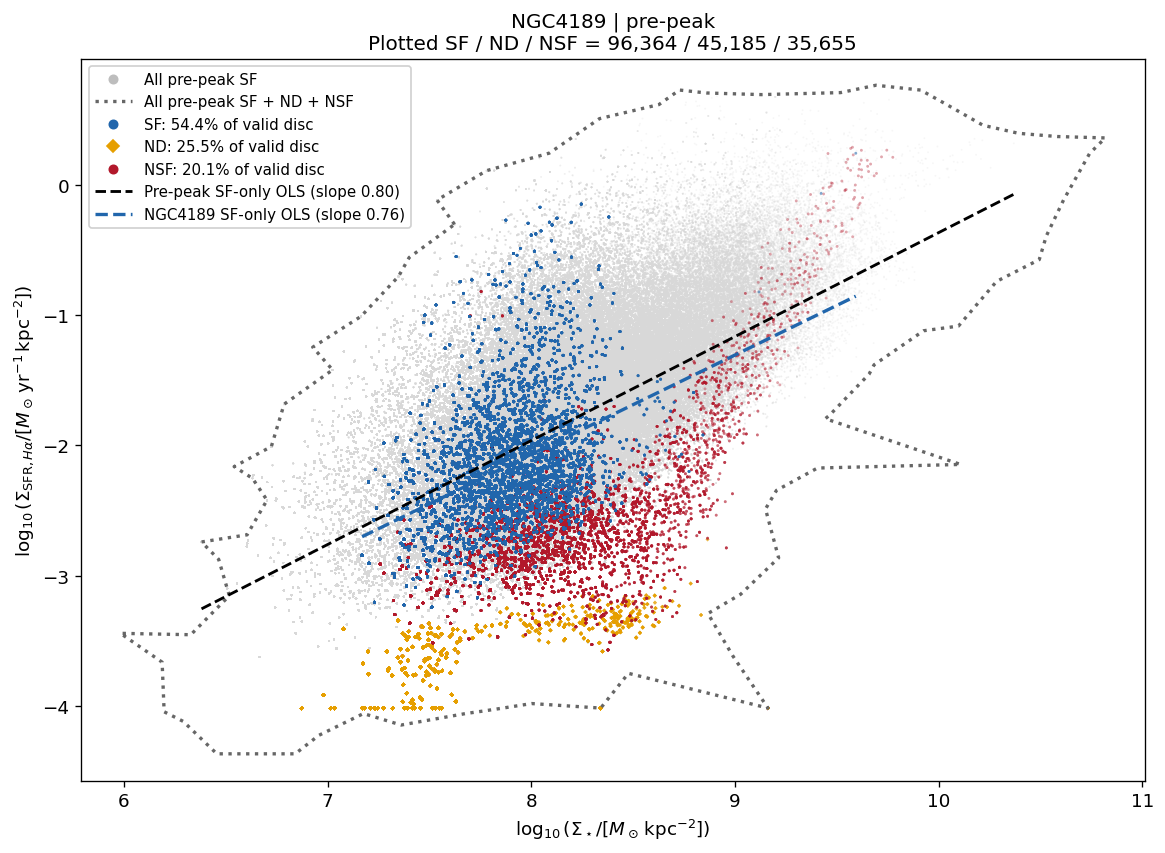

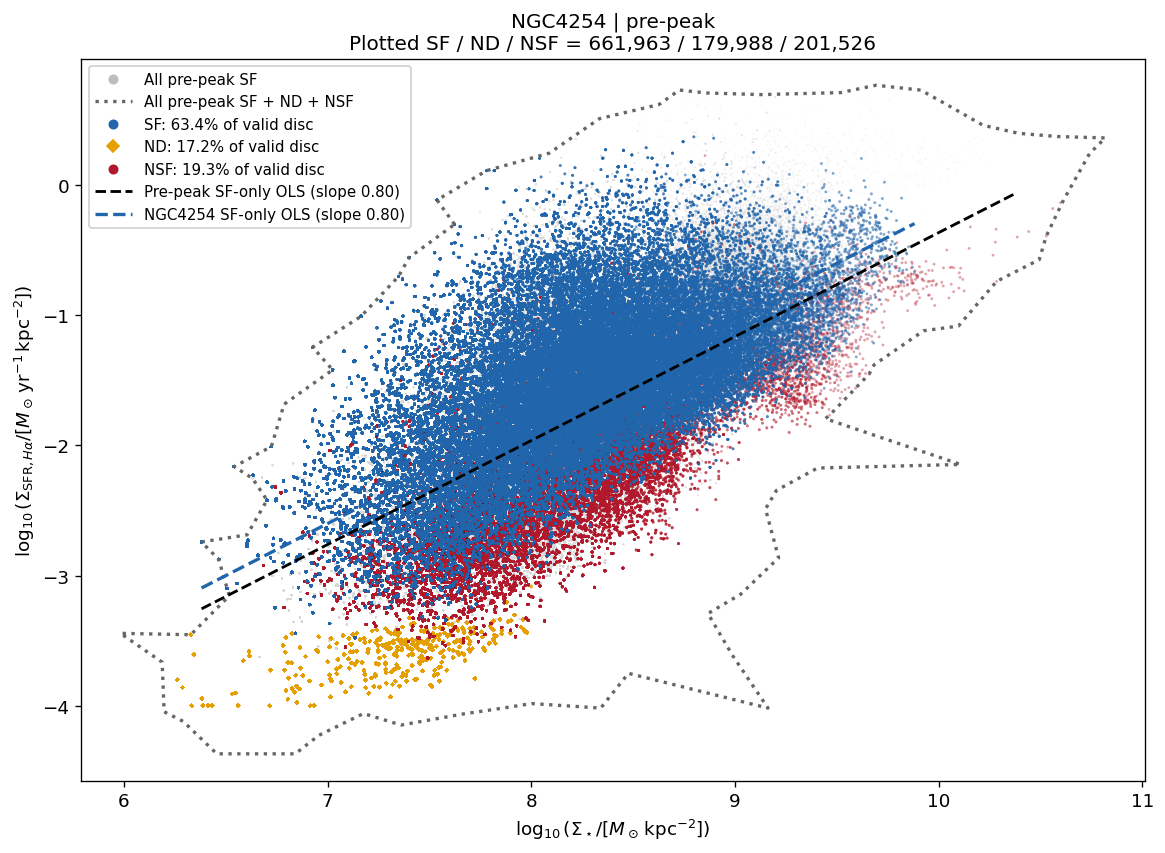

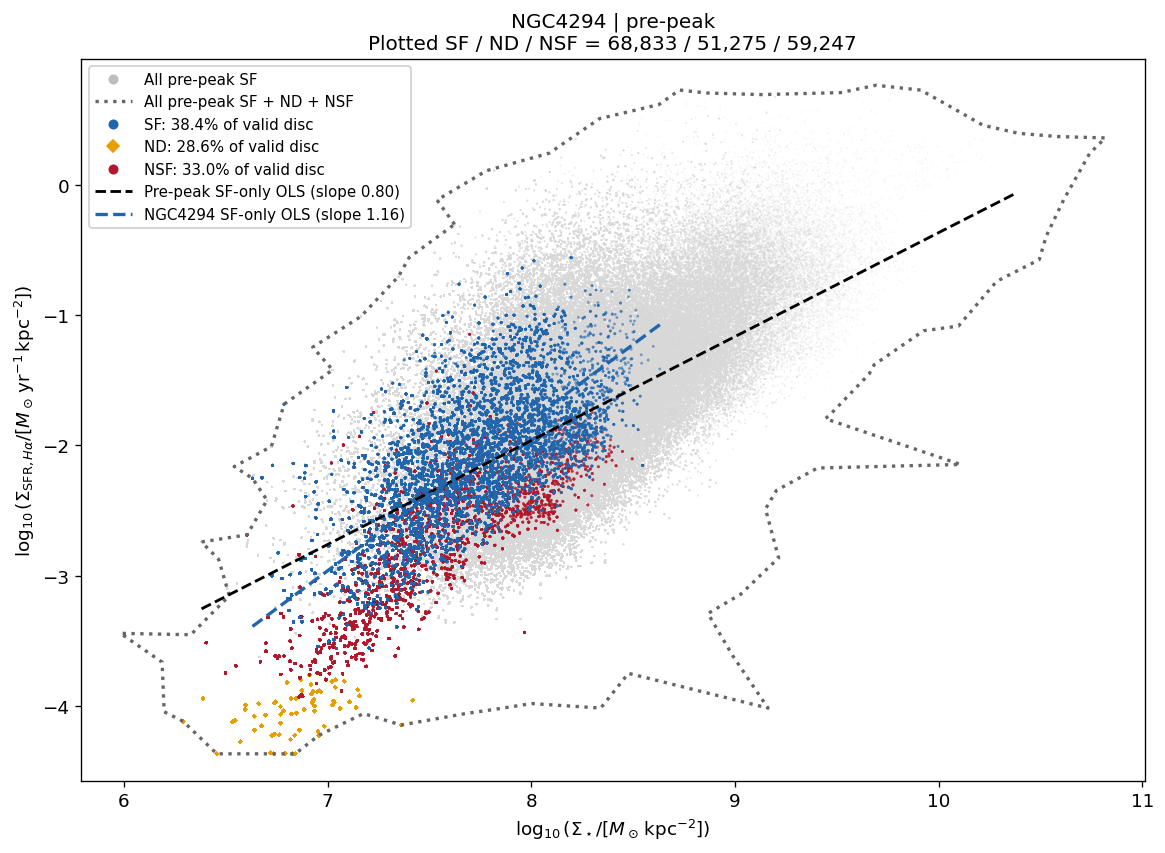

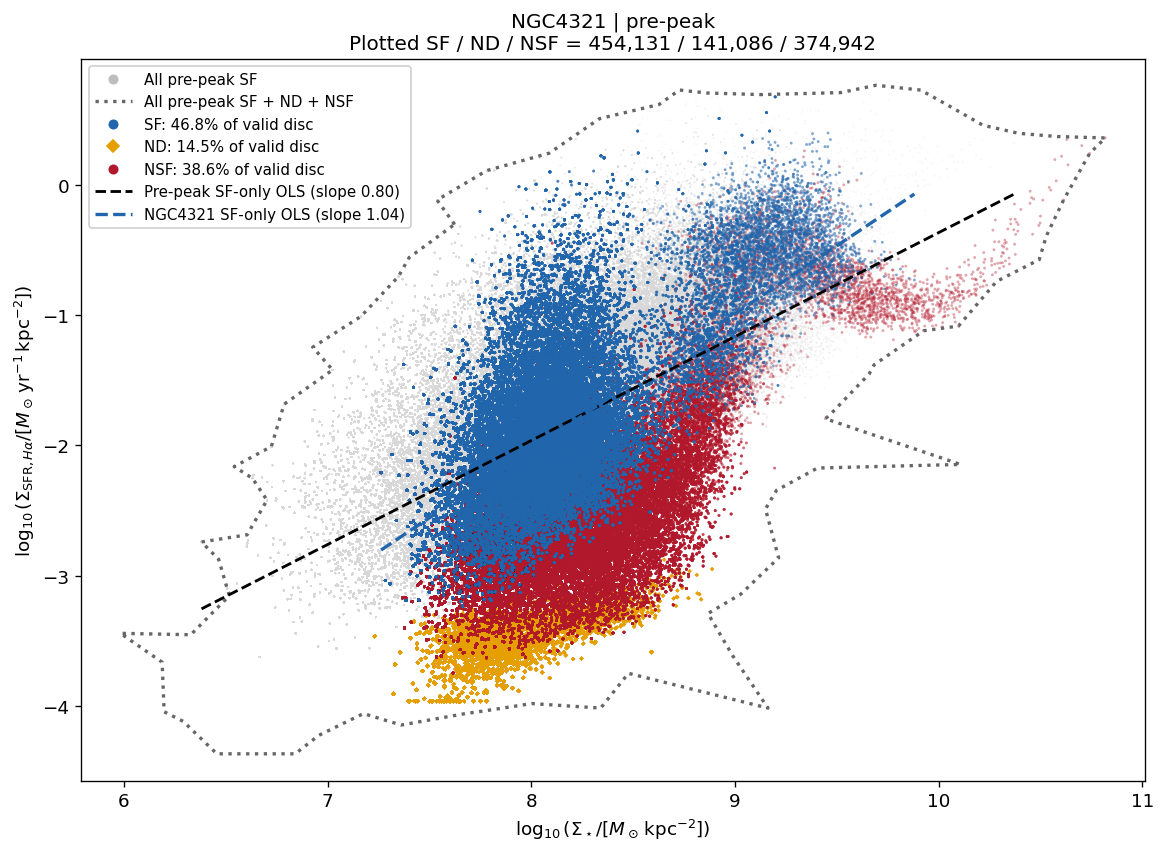

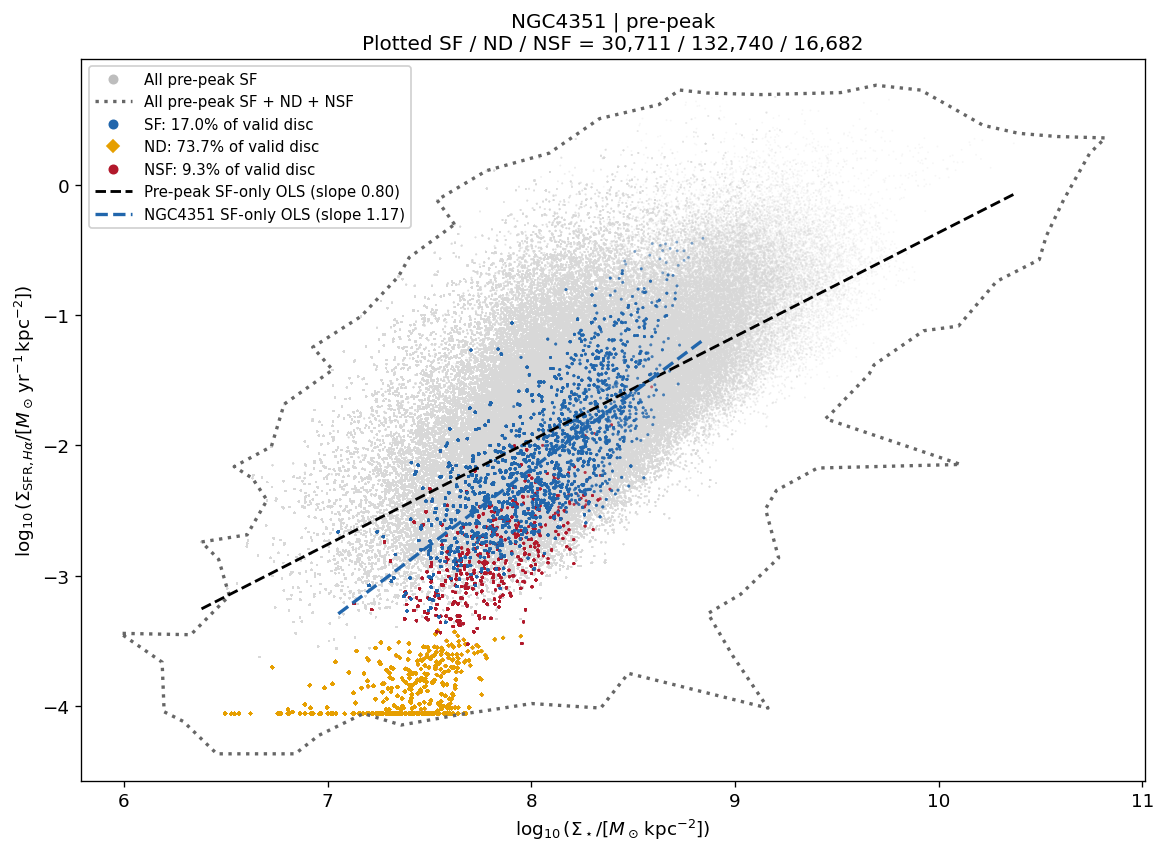

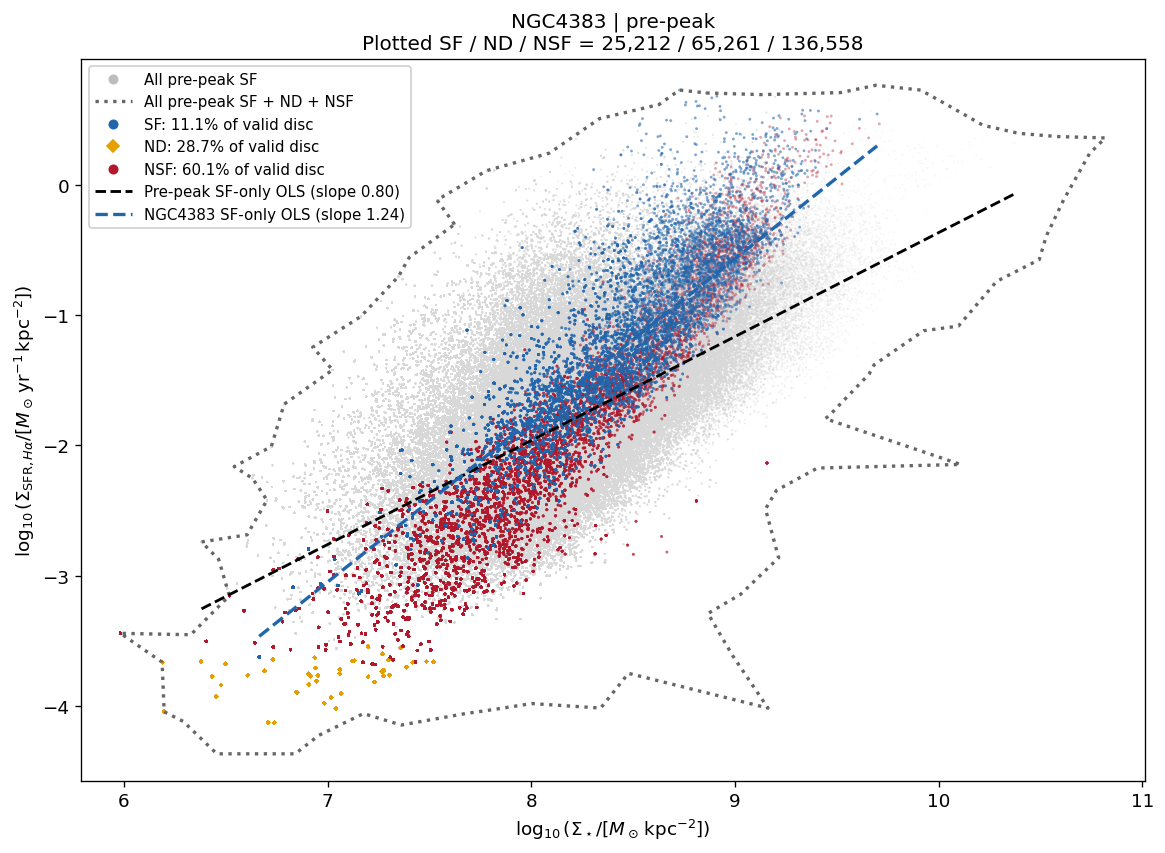

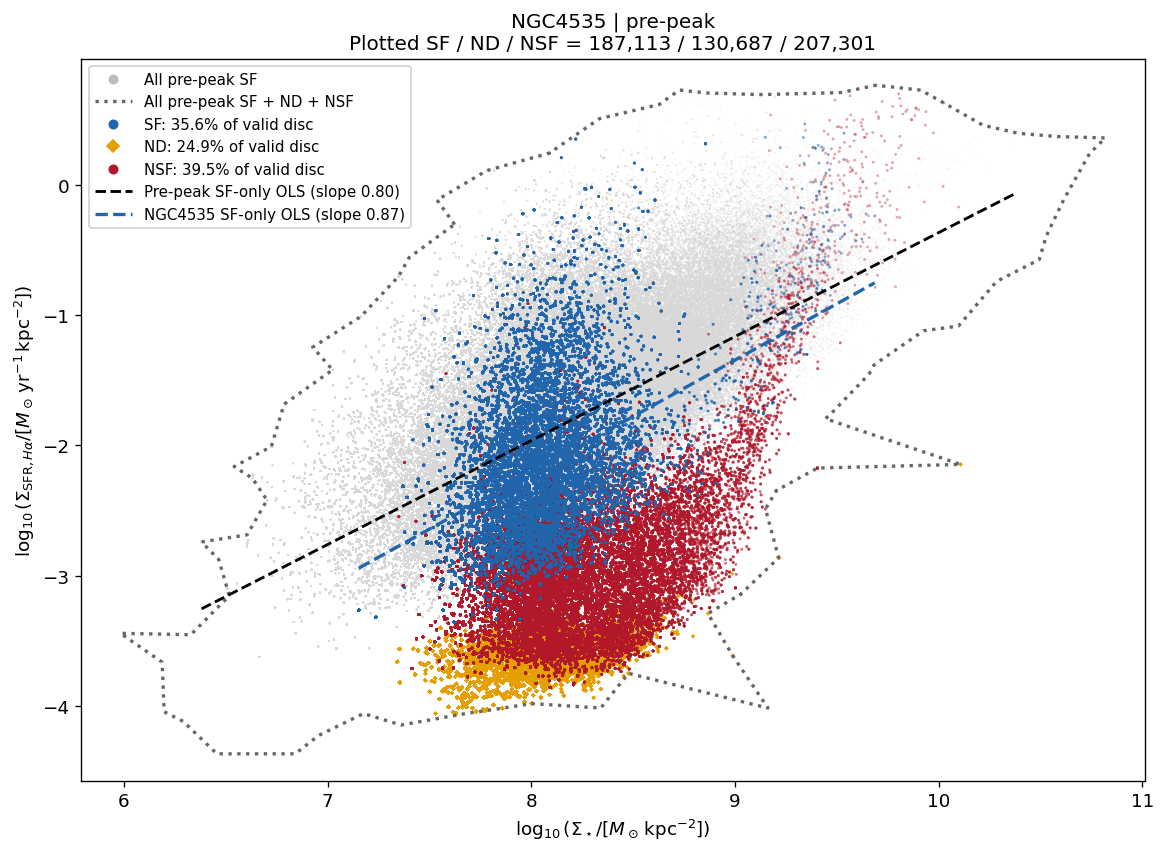

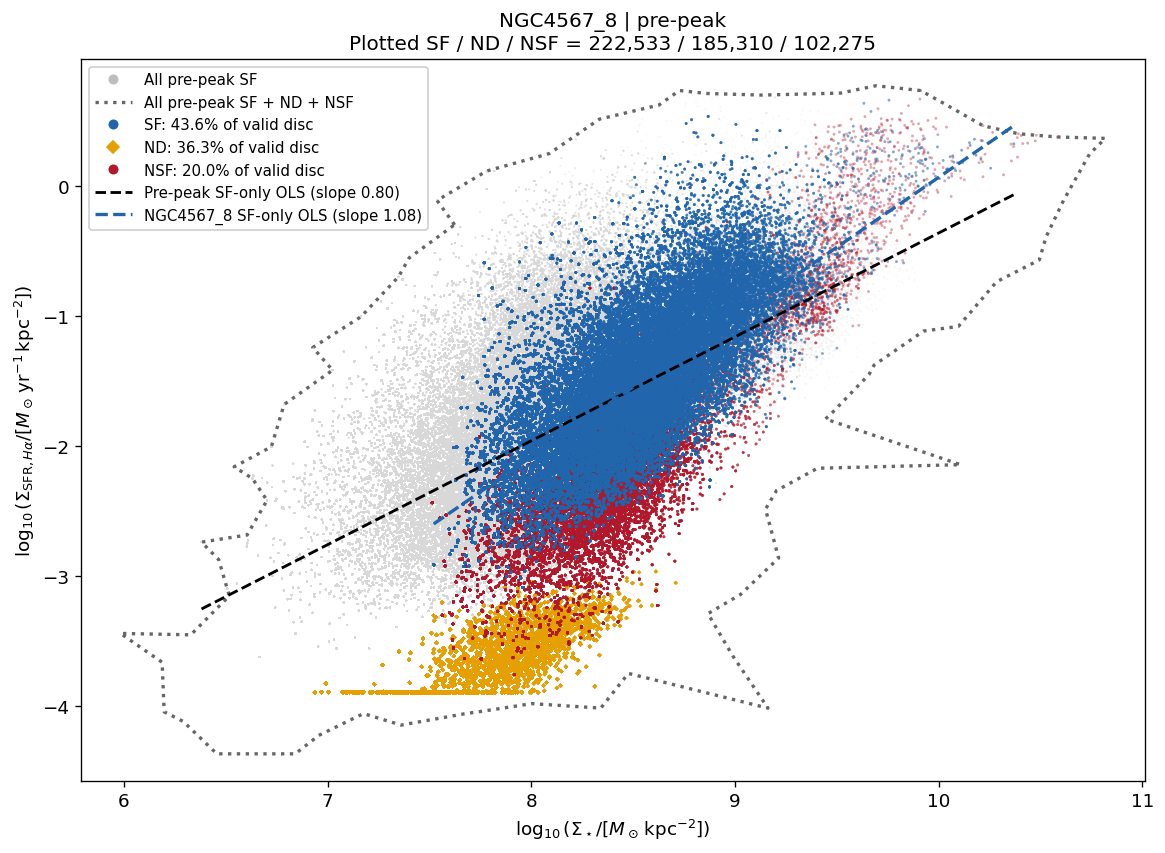

Verified: all finite category pixels were plotted, with no display subsampling.


In [6]:
from matplotlib.lines import Line2D
from shapely import MultiPoint, concave_hull


def full_limits(values, padding=0.04):
    lo, hi = float(np.min(values)), float(np.max(values))
    margin = padding * max(hi - lo, 0.5)
    return lo - margin, hi + margin


OUTLINE_CONCAVITY_RATIO = 0.15
all_prepeak_points = np.unique(np.column_stack((pooled_x, pooled_y)), axis=0)
all_prepeak_hull = concave_hull(
    MultiPoint(all_prepeak_points),
    ratio=OUTLINE_CONCAVITY_RATIO,
    allow_holes=False,
)
all_prepeak_outline = np.asarray(all_prepeak_hull.exterior.coords)
print(f"Dotted outline: connected outer points of all {pooled_x.size:,} finite "
      f"SF+ND+NSF pixels; no density smoothing or percentile cut.")

X_LIMITS = full_limits(pooled_x)
Y_LIMITS = full_limits(pooled_y)
PLOT_COUNTS = []

for row in prepeak.itertuples(index=False):
    galid = row.GALID
    maps, data = map_cache[galid], rsfms_cache[galid]
    fig, ax = plt.subplots(figsize=(9.6, 7.0), layout="constrained")
    ax.scatter(pooled_sf_x, pooled_sf_y, s=1.2, color="#d8d8d8", alpha=0.22,
               edgecolors="none", rasterized=True, zorder=1)
    # ND and NSF remain visibly distinct; SF is drawn last.
    style = {"ND": ("D", 3.0, 0.32), "NSF": ("o", 3.0, 0.38),
             "SF": ("o", 3.0, 0.55)}
    counts = {}
    for category in ("ND", "NSF", "SF"):
        mask = maps[CATEGORY_KEYS[category]] & data["finite_xy"]
        marker, size, alpha = style[category]
        counts[category] = int(mask.sum())
        ax.scatter(data["x"][mask], data["y"][mask], s=size, marker=marker,
                   color=CATEGORY_COLORS[category], alpha=alpha, edgecolors="none",
                   rasterized=True, zorder=2 if category == "ND" else 3 if category == "NSF" else 4)
    ax.plot(all_prepeak_outline[:, 0], all_prepeak_outline[:, 1],
            color="#666666", linestyle=":", lw=2.0, zorder=5)
    line_handles = []
    for fit, color, label, width in (
        (ensemble_ols, "black", "Pre-peak SF-only OLS", 1.7),
        (individual_ols[galid], CATEGORY_COLORS["SF"], f"{galid} SF-only OLS", 2.0),
    ):
        if fit["status"] == "OK":
            xx = np.linspace(fit["x_min"], fit["x_max"], 100)
            ax.plot(xx, fit["slope"] * (xx - OLS_PIVOT) + fit["intercept_at_8"],
                    color=color, linestyle="--", lw=width, zorder=6)
            line_handles.append(Line2D(
                [], [], color=color, ls="--", lw=width,
                label=f'{label} (slope {fit["slope"]:.2f})',
            ))
    n_valid = int(maps["valid_disc_mask"].sum())
    n_missing = int((maps["valid_disc_mask"] & ~data["finite_xy"]).sum())
    class_counts = {k: int(maps[v].sum()) for k, v in CATEGORY_KEYS.items()}
    handles = [Line2D([], [], color="#bdbdbd", marker="o", ls="none", ms=5,
                      label="All pre-peak SF"),
               Line2D([], [], color="#666666", ls=":", lw=2.0,
                      label="All pre-peak SF + ND + NSF")]
    handles += [
        Line2D([], [], color=CATEGORY_COLORS[k], marker=style[k][0], ls="none", ms=5,
               label=f'{k}: {class_counts[k] / n_valid:.1%} of valid disc')
        for k in ("SF", "ND", "NSF")
    ]
    ax.legend(handles=handles + line_handles, loc="upper left", fontsize=9,
              frameon=True, framealpha=0.92, handlelength=2.5)
    ax.set(xlim=X_LIMITS, ylim=Y_LIMITS,
           xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
           ylabel=r"$\log_{10}(\Sigma_{\mathrm{SFR},H\alpha}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$")
    ax.set_title(
        f"{galid} | pre-peak\n"
        f"Plotted SF / ND / NSF = {counts['SF']:,} / {counts['ND']:,} / {counts['NSF']:,}", fontsize=12,
    )
    # fig.suptitle(
    #     "Selected SF versus Halpha-equivalent/proxy ordinates\n"
    #     "ND substitutions are not formal upper limits; both OLS guides fit selected SF only",
    #     fontsize=10, color="#444444",
    # )
    PLOT_COUNTS.append({"GALID": galid, **counts, "N_missing_y": n_missing})
    plt.show()
    plt.close(fig)

PLOT_COUNTS = pd.DataFrame(PLOT_COUNTS)
expected_counts = CATEGORY_COVERAGE.pivot(index="GALID", columns="category", values="N_plotted")
for category in CATEGORY_KEYS:
    np.testing.assert_array_equal(
        PLOT_COUNTS.set_index("GALID")[category].sort_index().to_numpy(),
        expected_counts[category].sort_index().to_numpy(),
    )
print("Verified: all finite category pixels were plotted, with no display subsampling.")


## 7. Reading this diagnostic

- Compare each coloured class with the same grey pre-peak SF-only reference,
  the dotted all-category outer-point outline, and the black SF-only line. The blue
  line describes the selected-SF locus within the
  individual product, not the locus of its full disc.
- An ND pile-up at the lower edge must first be checked against the raw-Halpha
  floor count in `ND_DETAILS`. Do not treat this pile-up as a measured low-SFR
  sequence or as a distribution of formal upper limits.
- Use the Halpha-detected/Hbeta-failed count to separate missing dust information
  from Halpha non-detections. The three-category colours intentionally retain
  the source definitions; they do not reclassify Hbeta-only failures.
- Red NSF points can reveal where the SF-selection gate removes high
  Halpha-equivalent values, but their offset is not by itself SF enhancement,
  suppression, or an upper confidence bound on the true SFR.
- This notebook visualises the selection problem. Testing how censored points
  change the rSFMS would be a separate step: specify a per-spaxel flux-limit
  construction, attenuation assumptions, the treatment of NSF contamination,
  and a censored fitting model before interpreting changes in slope.

### Provenance

Source notebook SHA-256 at creation:
`92faee8f486a6b0e2a87d36ca1d2bd6051ece0c7b806c123a96679d0e6b4416f`.

Configuration (source cell 3) and inventory (source cell 7) are retained;
relevant mask helpers come from source cell 5. The all-spaxel SFR construction
was traced through `modify_Balmer_not_detected_map`, `LOG_SFR_surface_density_map`,
and the FITS-output block in the local `SFR+Z.py`. The runtime provenance table
records the actual product paths and key headers. No source notebook, pipeline,
catalogue, or FITS file is modified.


In [7]:
n_total = int(CATEGORY_COVERAGE.groupby("GALID").N_valid.first().sum())
n_missing = int(CATEGORY_COVERAGE.N_missing_y.sum())
print(f"Current run: {len(prepeak)} pre-peak products; {n_total:,} valid-disc pixels.")
for category in CATEGORY_KEYS:
    subset = CATEGORY_COVERAGE.loc[CATEGORY_COVERAGE.category.eq(category)]
    print(f"{category}: {int(subset.N_class.sum()):,} class pixels; "
          f"{int(subset.N_plotted.sum()):,} finite plotted ordinates; "
          f"{int(subset.N_missing_y.sum()):,} missing ordinates.")
print(f"Total missing ordinates: {n_missing:,}. These remain counted in the original denominator.")
print("No ND or NSF points enter either OLS guide. No censored regression has been performed.")


Current run: 8 pre-peak products; 3,812,578 valid-disc pixels.
SF: 1,746,860 class pixels; 1,746,860 finite plotted ordinates; 0 missing ordinates.
ND: 931,532 class pixels; 931,532 finite plotted ordinates; 0 missing ordinates.
NSF: 1,134,186 class pixels; 1,134,186 finite plotted ordinates; 0 missing ordinates.
Total missing ordinates: 0. These remain counted in the original denominator.
No ND or NSF points enter either OLS guide. No censored regression has been performed.


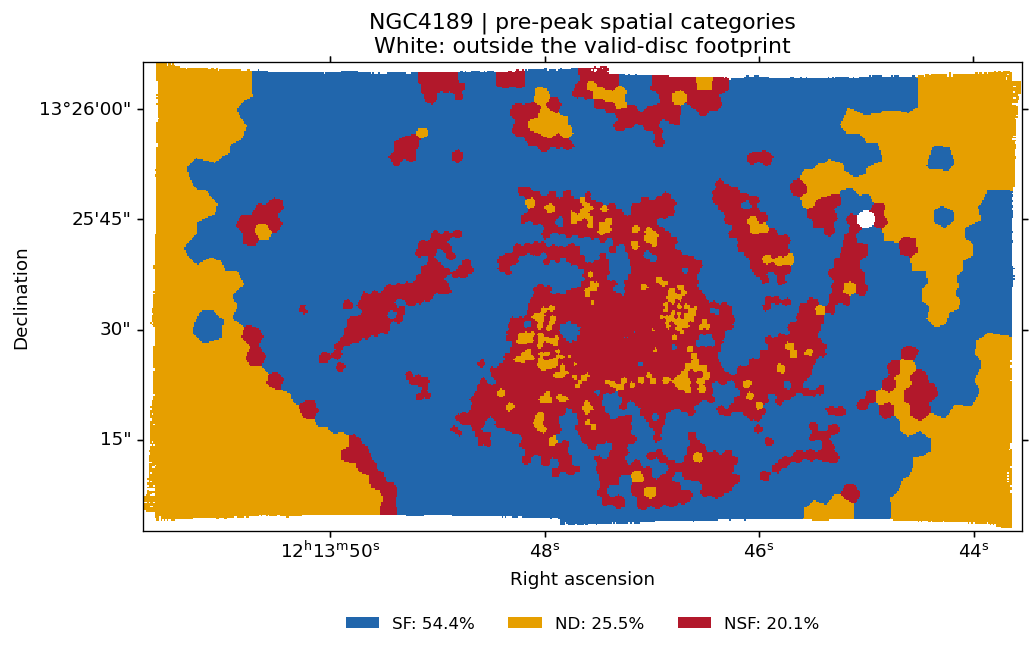

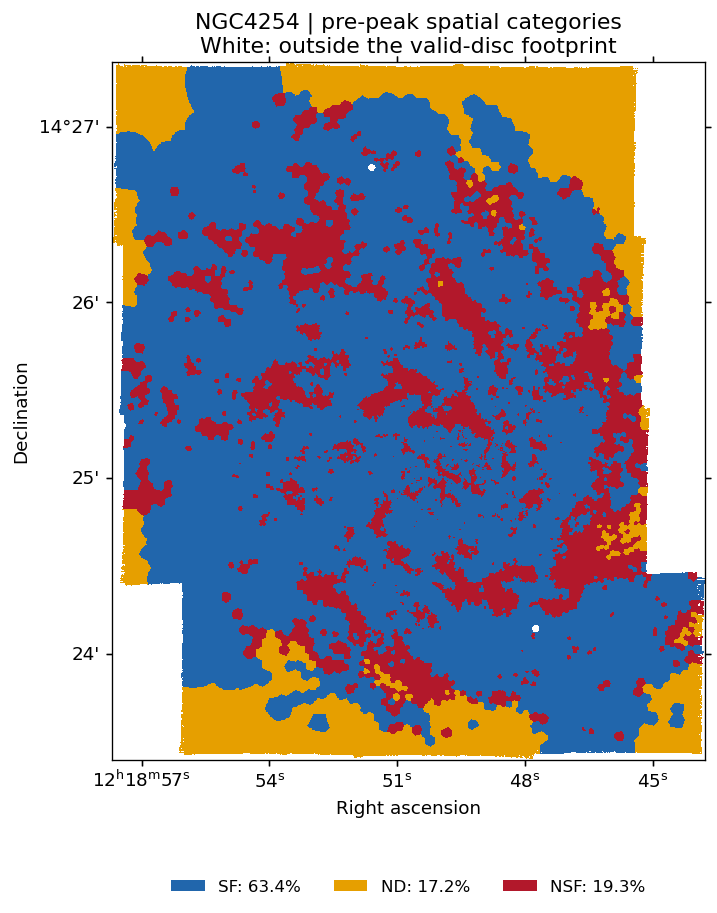

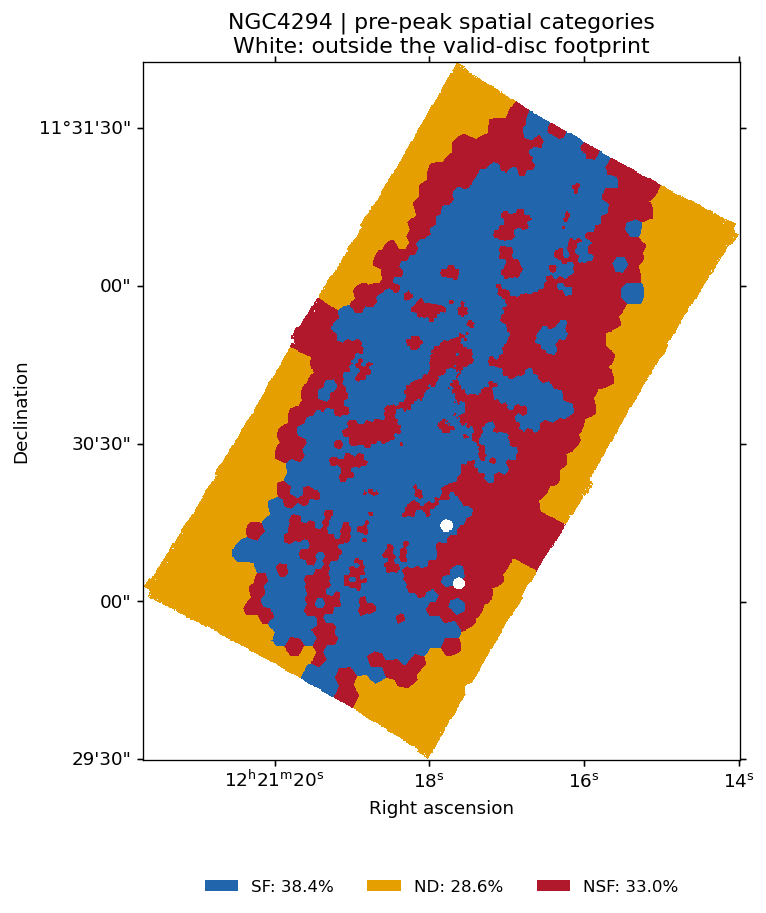

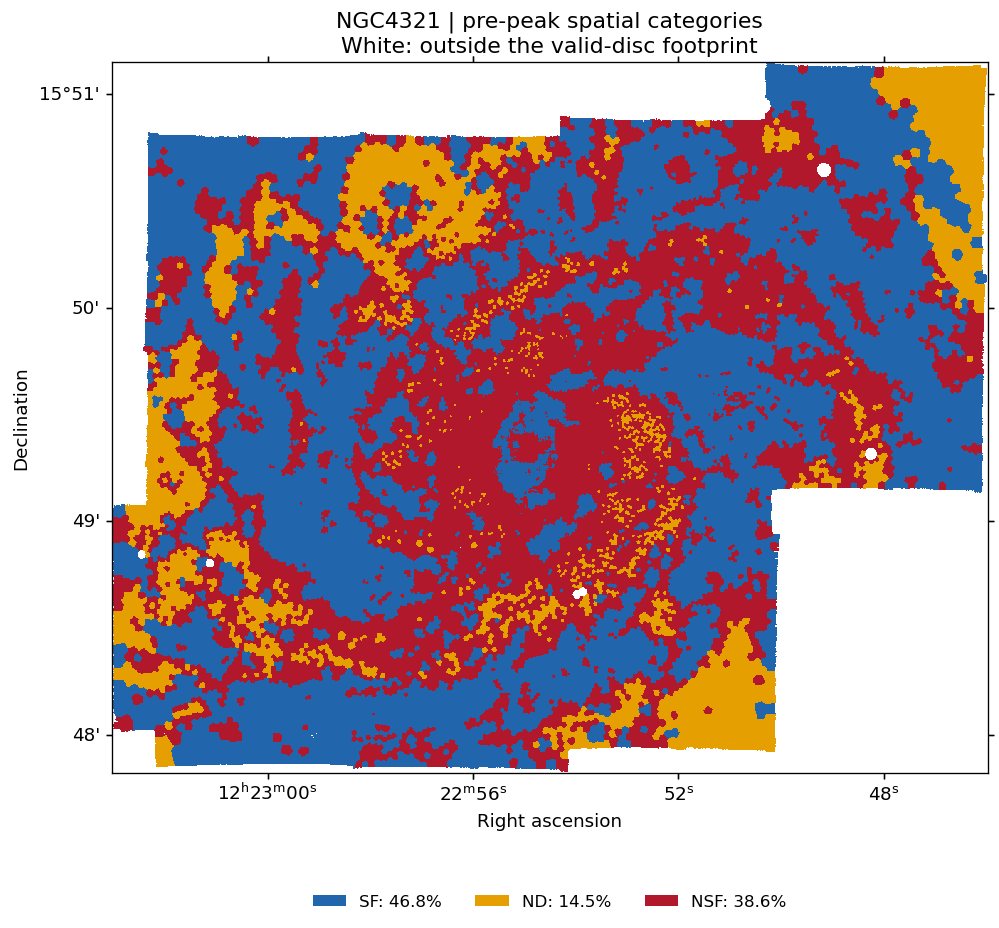

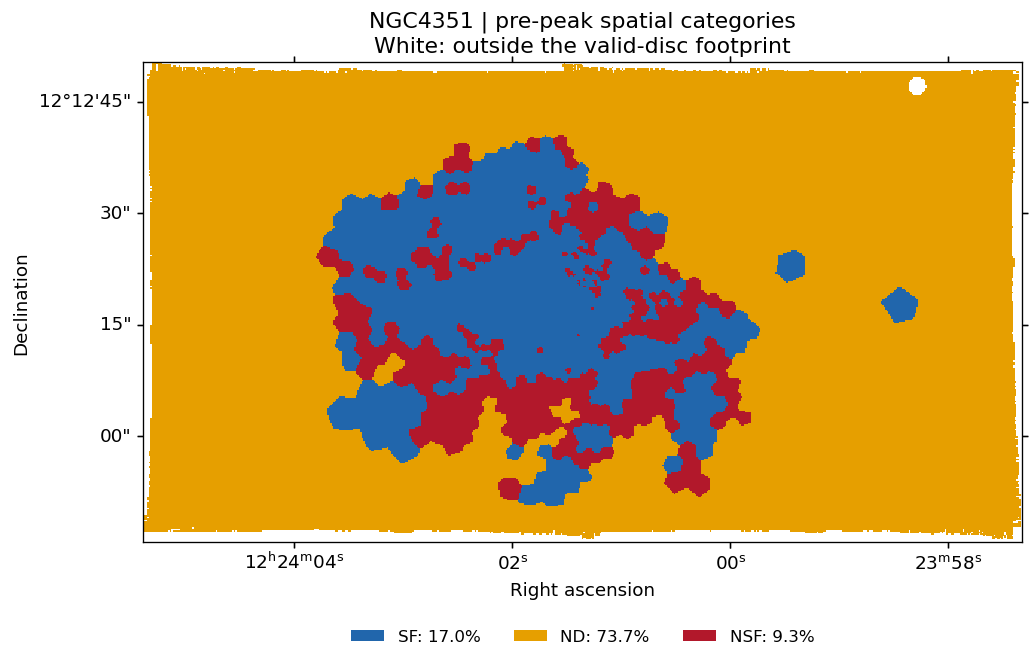

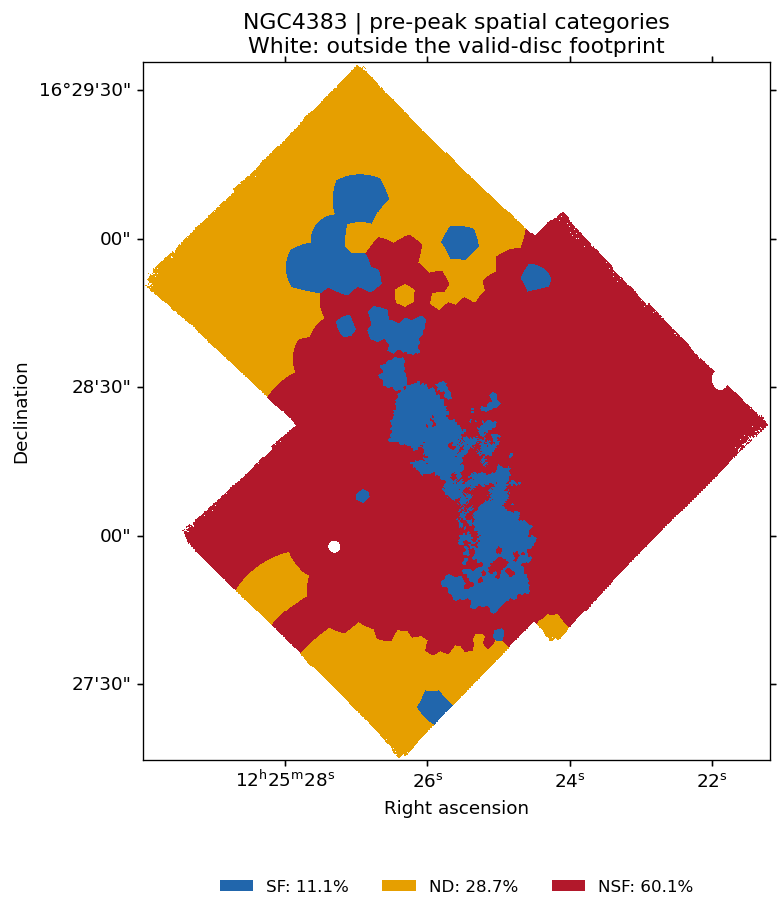

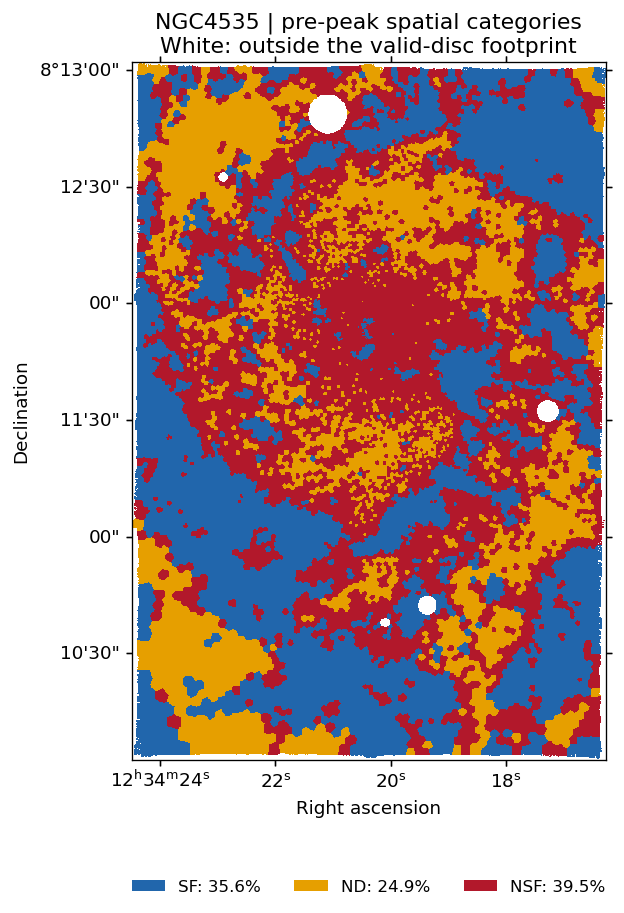

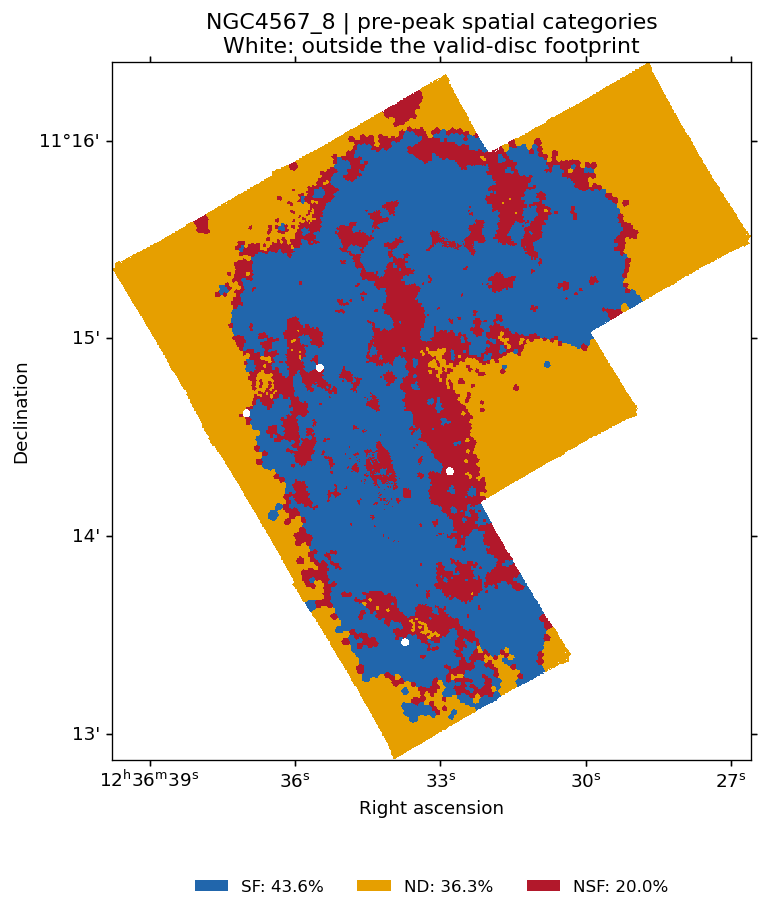

In [8]:
# Spatial SF/ND/NSF categories on the unchanged valid-disc footprint.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

spatial_category_labels = ("SF", "ND", "NSF")
spatial_category_keys = ("sf_mask", "nd_mask", "nsf_mask")
spatial_category_cmap = ListedColormap(
    [CATEGORY_COLORS[label] for label in spatial_category_labels]
)
spatial_category_cmap.set_bad("white")
spatial_category_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)

for row in prepeak.itertuples(index=False):
    maps = map_cache[row.GALID]
    valid = maps["valid_disc_mask"]
    category_map = np.full(valid.shape, np.nan)
    for code, key in enumerate(spatial_category_keys):
        category_map[valid & maps[key]] = code

    fig = plt.figure(figsize=(8.5, 7.5), layout="constrained")
    ax = fig.add_subplot(111, projection=WCS(maps["mass_header"]).celestial)
    ax.imshow(np.ma.masked_invalid(category_map), origin="lower",
              interpolation="nearest", cmap=spatial_category_cmap,
              norm=spatial_category_norm, aspect="equal")
    ax.coords[0].set_axislabel("Right ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.set_title(f"{row.GALID} | pre-peak spatial categories\n"
                 "White: outside the valid-disc footprint")
    handles = [
        Patch(facecolor=CATEGORY_COLORS[label], edgecolor="none",
              label=f"{label}: {np.count_nonzero(valid & maps[key]) / valid.sum():.1%}")
        for label, key in zip(spatial_category_labels, spatial_category_keys)
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=3, frameon=False, fontsize=10)
    plt.show()
    plt.close(fig)
